# Morpion Adaptatif — Pipeline Machine Learning
**Institut Supérieur Polytechnique de Madagascar**  
Examen Final — Semestre 1 — Machine Learning

---

## Table des matières
1. [Imports & Chargement du dataset](#etape0)
2. [Étape 1 — EDA](#etape1)
3. [Étape 2 — Baseline : Régression Logistique](#etape2)
4. [Étape 3 — Modèles Avancés](#etape3)
5. [Résumé comparatif final](#resume)

---
## 0. Imports & Chargement du dataset <a id='etape0'></a>

In [25]:
# ── Librairies ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

print('Librairies importées avec succès !')

Librairies importées avec succès !


In [26]:
# ── Chargement du dataset ────────────────────────────────────
# Sur Google Colab : uploader le fichier dataset.csv
# from google.colab import files
# files.upload()
# df = pd.read_csv('dataset.csv')

# En local : chemin direct
df = pd.read_csv('ressources/dataset.csv')

print('Nombre de lignes    :', len(df))
print('Nombre de colonnes  :', len(df.columns))
print()
print('=== Distribution x_wins ===')
print(df['x_wins'].value_counts())
print()
print('=== Distribution is_draw ===')
print(df['is_draw'].value_counts())
df.head()

Nombre de lignes    : 2423
Nombre de colonnes  : 20

=== Distribution x_wins ===
x_wins
1    1830
0     593
Name: count, dtype: int64

=== Distribution is_draw ===
is_draw
0    1982
1     441
Name: count, dtype: int64


,c0_x,c1_x,c2_x,c3_x,c4_x,c5_x,c6_x,c7_x,c8_x,c0_o,c1_o,c2_o,c3_o,c4_o,c5_o,c6_o,c7_o,c8_o,x_wins,is_draw
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
2,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0
3,1,0,1,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0
4,1,0,1,0,1,0,0,1,0,0,1,0,1,0,1,1,0,0,1,0


In [27]:
# ── Vérification qualité ─────────────────────────────────────
print('Valeurs manquantes par colonne :')
print(df.isnull().sum().sum(), 'valeur(s) manquante(s) au total')
print()
print('Types des colonnes :')
print(df.dtypes.value_counts())

Valeurs manquantes par colonne :
0 valeur(s) manquante(s) au total

Types des colonnes :
int64    20
Name: count, dtype: int64


---
## 1. Étape 1 — EDA (Exploratory Data Analysis) <a id='etape1'></a>

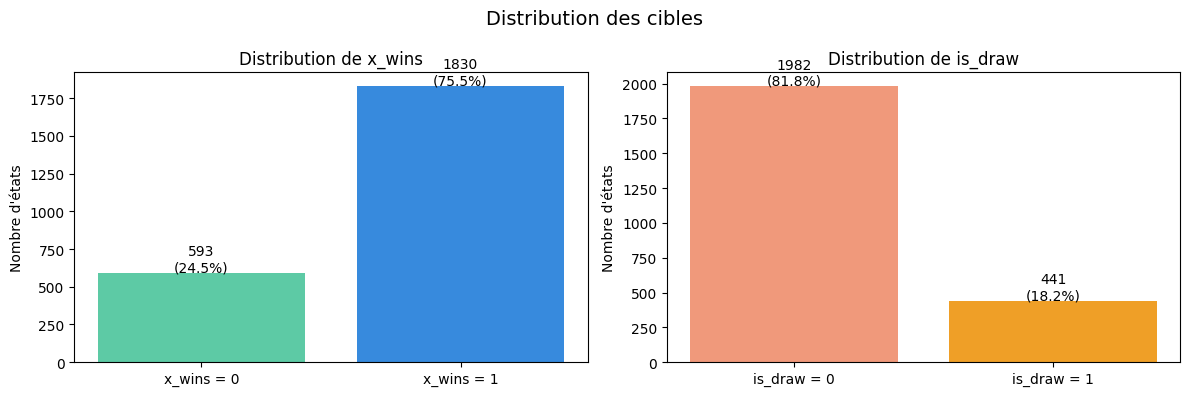

In [28]:
# ── 1.1 Distribution des cibles ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['x_wins = 0', 'x_wins = 1'],
            df['x_wins'].value_counts().sort_index(),
            color=['#5DCAA5', '#378ADD'])
axes[0].set_title('Distribution de x_wins')
axes[0].set_ylabel("Nombre d'états")
for i, v in enumerate(df['x_wins'].value_counts().sort_index()):
    axes[0].text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10)

axes[1].bar(['is_draw = 0', 'is_draw = 1'],
            df['is_draw'].value_counts().sort_index(),
            color=['#F0997B', '#EF9F27'])
axes[1].set_title('Distribution de is_draw')
axes[1].set_ylabel("Nombre d'états")
for i, v in enumerate(df['is_draw'].value_counts().sort_index()):
    axes[1].text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10)

plt.suptitle('Distribution des cibles', fontsize=14)
plt.tight_layout()
plt.show()

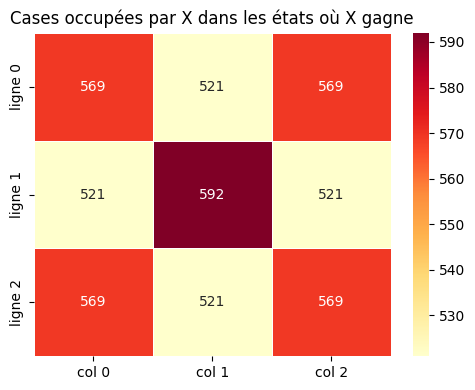

In [29]:
# ── 1.2 Quelle case X occupe le plus quand il gagne ? ────────
df_xwins = df[df['x_wins'] == 1]
occupation_x = [df_xwins[f'c{i}_x'].sum() for i in range(9)]
occupation_grid = np.array(occupation_x).reshape(3, 3)

plt.figure(figsize=(5, 4))
sns.heatmap(occupation_grid, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5,
            xticklabels=['col 0', 'col 1', 'col 2'],
            yticklabels=['ligne 0', 'ligne 1', 'ligne 2'])
plt.title('Cases occupées par X dans les états où X gagne')
plt.tight_layout()
plt.show()

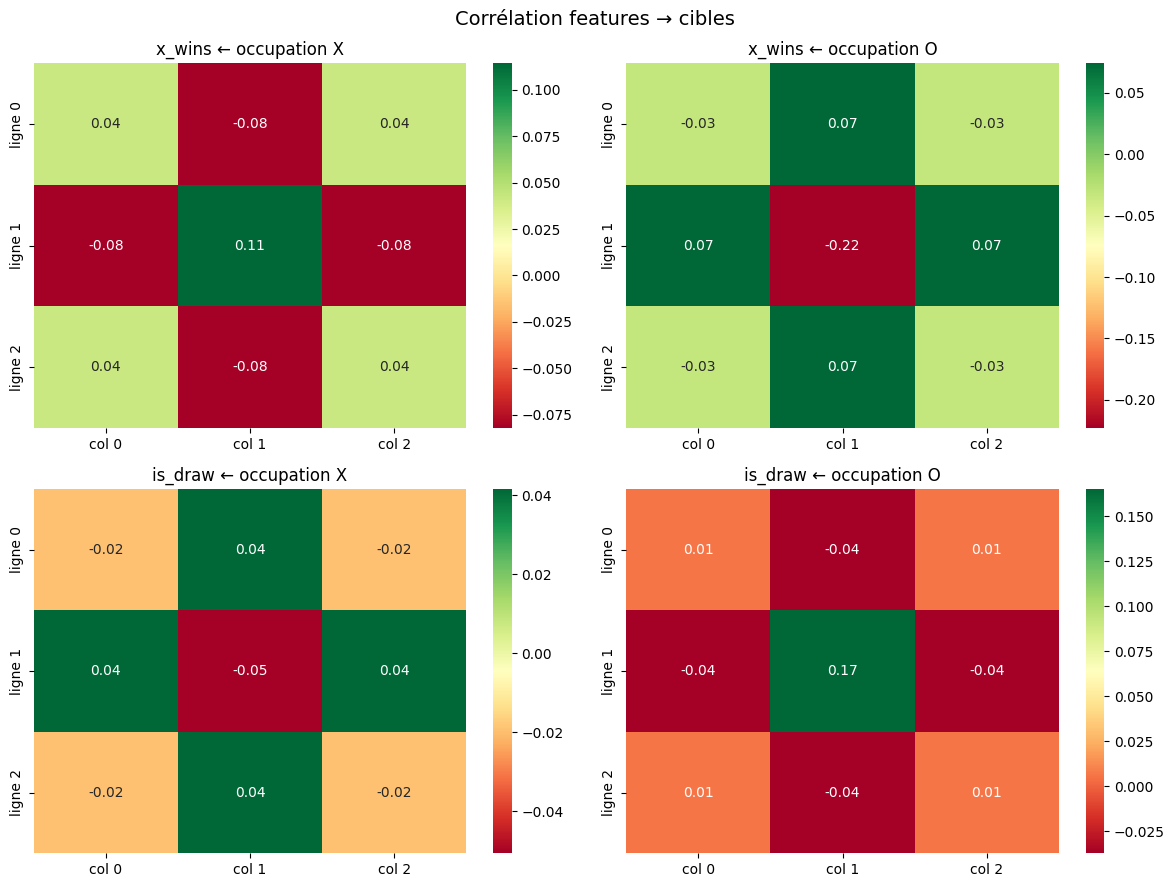

In [30]:
# ── 1.3 Heatmap de corrélation features → cibles ─────────────
features_cols = [f'c{i}_x' for i in range(9)] + [f'c{i}_o' for i in range(9)]

corr_xwins = df[features_cols].corrwith(df['x_wins'])
corr_draw  = df[features_cols].corrwith(df['is_draw'])

corr_xwins_grid_x = corr_xwins[:9].values.reshape(3, 3)
corr_xwins_grid_o = corr_xwins[9:].values.reshape(3, 3)
corr_draw_grid_x  = corr_draw[:9].values.reshape(3, 3)
corr_draw_grid_o  = corr_draw[9:].values.reshape(3, 3)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Corrélation features → cibles', fontsize=14)
labels_x = ['col 0', 'col 1', 'col 2']
labels_y = ['ligne 0', 'ligne 1', 'ligne 2']

sns.heatmap(corr_xwins_grid_x, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[0][0], xticklabels=labels_x, yticklabels=labels_y)
axes[0][0].set_title('x_wins ← occupation X')

sns.heatmap(corr_xwins_grid_o, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[0][1], xticklabels=labels_x, yticklabels=labels_y)
axes[0][1].set_title('x_wins ← occupation O')

sns.heatmap(corr_draw_grid_x, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1][0], xticklabels=labels_x, yticklabels=labels_y)
axes[1][0].set_title('is_draw ← occupation X')

sns.heatmap(corr_draw_grid_o, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1][1], xticklabels=labels_x, yticklabels=labels_y)
axes[1][1].set_title('is_draw ← occupation O')

plt.tight_layout()
plt.show()

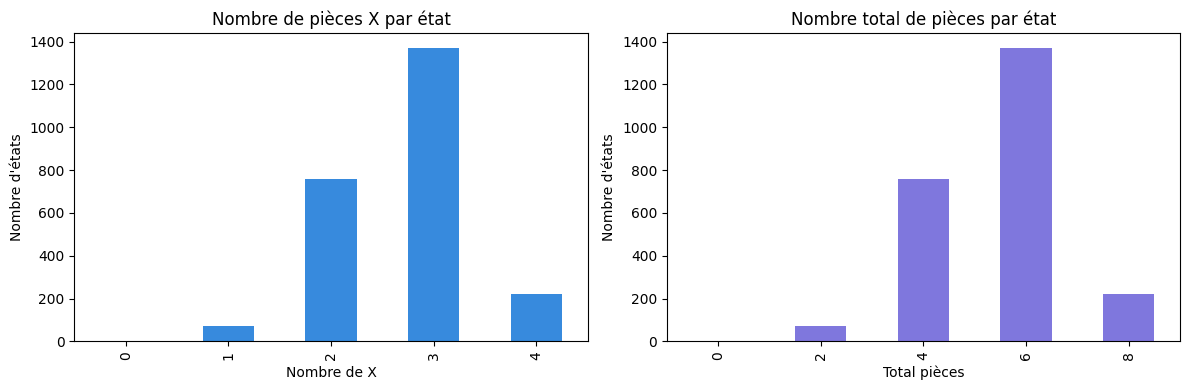

In [31]:
# ── 1.4 Nombre de pièces sur le plateau ──────────────────────
df['nb_x']     = df[[f'c{i}_x' for i in range(9)]].sum(axis=1)
df['nb_o']     = df[[f'c{i}_o' for i in range(9)]].sum(axis=1)
df['nb_total'] = df['nb_x'] + df['nb_o']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['nb_x'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#378ADD')
axes[0].set_title('Nombre de pièces X par état')
axes[0].set_xlabel('Nombre de X')
axes[0].set_ylabel("Nombre d'états")

df['nb_total'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#7F77DD')
axes[1].set_title('Nombre total de pièces par état')
axes[1].set_xlabel('Total pièces')
axes[1].set_ylabel("Nombre d'états")

plt.tight_layout()
plt.show()

---
### Reponse des question:
 x_wins : Déséquilibré — X gagne dans 3 états sur 4 en jeu parfait </br>
 is_draw : Très déséquilibré — les matchs nuls sont rares, seulement 1 état sur 5.

</br>
Le  plus souvent occupée par X dans les états où il gagne est la case L1C1 ou la case 4

</br>
</br>
 Laisser O prendre le centre nuit plus à X que X prenant le centre ne l'aide.


---
## 2. Étape 2 — Baseline : Régression Logistique <a id='etape2'></a>

In [32]:
# ── 2.1 Préparation des données ──────────────────────────────
X = df[[f'c{i}_x' for i in range(9)] + [f'c{i}_o' for i in range(9)]]
y_xwins = df['x_wins']
y_draw  = df['is_draw']

X_train, X_test, y_train_xw, y_test_xw = train_test_split(
    X, y_xwins, test_size=0.2, random_state=42)
X_train, X_test, y_train_dr, y_test_dr = train_test_split(
    X, y_draw, test_size=0.2, random_state=42)

print('Train :', len(X_train), 'lignes')
print('Test  :', len(X_test),  'lignes')

Train : 1938 lignes
Test  : 485 lignes


In [33]:
# ── 2.2 Fonction d'évaluation réutilisable ───────────────────
def evaluer_modele(nom, model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    print(f'=== {nom} ===')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    print()
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Matrice de confusion — {nom}')
    plt.show()
    return acc, f1

print('Fonction evaluer_modele() prête !')

Fonction evaluer_modele() prête !


In [34]:
# ── 2.3 Entraînement des 2 modèles baseline ──────────────────
model_xw = LogisticRegression(max_iter=1000)
model_xw.fit(X_train, y_train_xw)

model_dr = LogisticRegression(max_iter=1000)
model_dr.fit(X_train, y_train_dr)

print('Modèles Régression Logistique entraînés !')

Modèles Régression Logistique entraînés !


=== Régression Logistique — x_wins ===
  Accuracy : 0.7876
  F1-Score : 0.7336



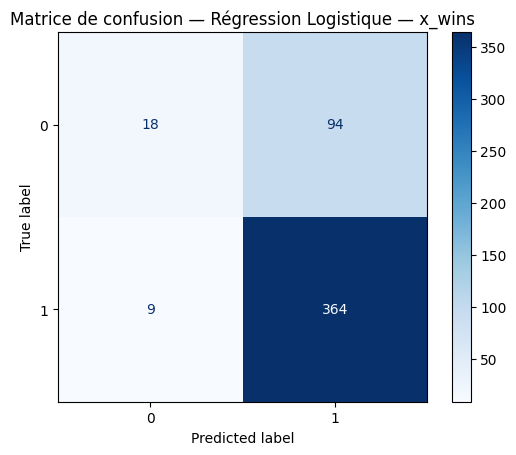

=== Régression Logistique — is_draw ===
  Accuracy : 0.8268
  F1-Score : 0.7484



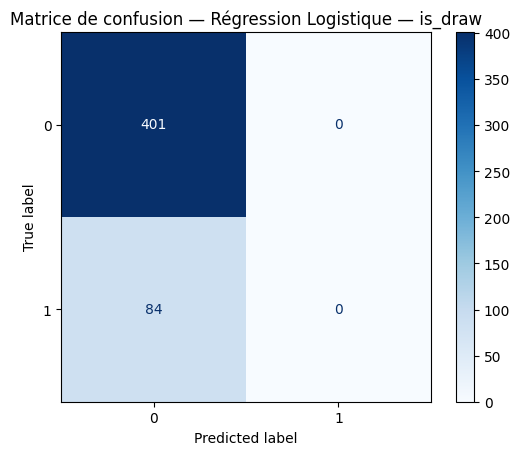

In [35]:
# ── 2.4 Évaluation baseline ──────────────────────────────────
acc_xw_lr, f1_xw_lr = evaluer_modele(
    'Régression Logistique — x_wins', model_xw, X_test, y_test_xw)
acc_dr_lr, f1_dr_lr = evaluer_modele(
    'Régression Logistique — is_draw', model_dr, X_test, y_test_dr)

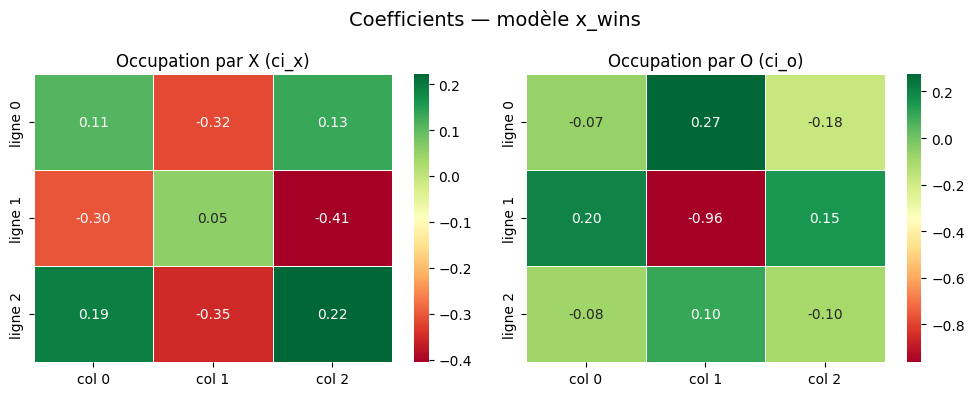

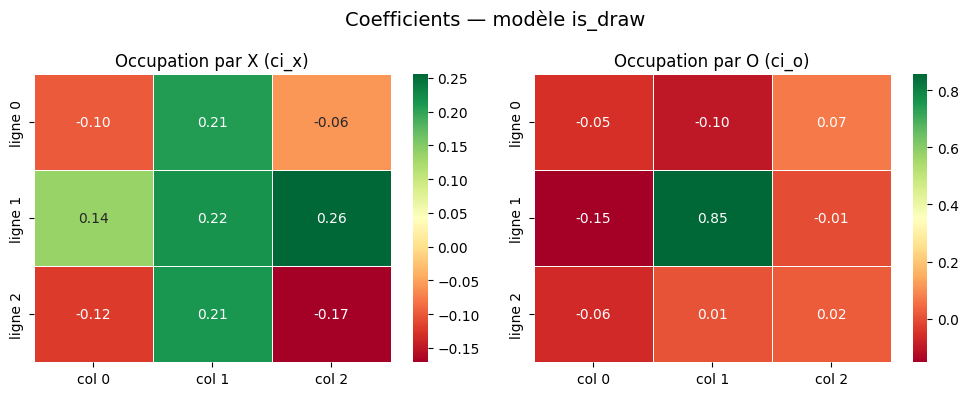

In [36]:
# ── 2.5 Visualisation des coefficients ──────────────────────
def afficher_coefficients(nom, model):
    coefs   = model.coef_[0]
    coefs_x = coefs[:9].reshape(3, 3)
    coefs_o = coefs[9:].reshape(3, 3)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f'Coefficients — modèle {nom}', fontsize=14)

    sns.heatmap(coefs_x, annot=True, fmt='.2f', cmap='RdYlGn',
                ax=axes[0], linewidths=0.5,
                xticklabels=['col 0','col 1','col 2'],
                yticklabels=['ligne 0','ligne 1','ligne 2'])
    axes[0].set_title('Occupation par X (ci_x)')

    sns.heatmap(coefs_o, annot=True, fmt='.2f', cmap='RdYlGn',
                ax=axes[1], linewidths=0.5,
                xticklabels=['col 0','col 1','col 2'],
                yticklabels=['ligne 0','ligne 1','ligne 2'])
    axes[1].set_title('Occupation par O (ci_o)')

    plt.tight_layout()
    plt.show()

afficher_coefficients('x_wins',  model_xw)
afficher_coefficients('is_draw', model_dr)

---
### Reponse des question:
Matrices de confusion : les modèles ont tendance à prédire la classe majoritaire — x_wins = 1 pour le premier et is_draw = 0 pour le second.

---
## 3. Étape 3 — Modèles Avancés <a id='etape3'></a>

=== Decision Tree — x_wins ===
  Accuracy : 0.7918
  F1-Score : 0.7972



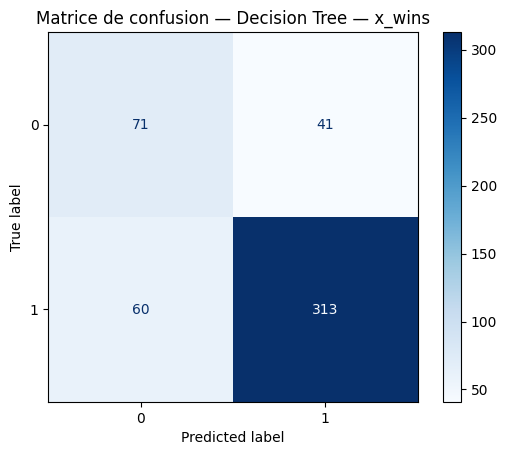

=== Decision Tree — is_draw ===
  Accuracy : 0.8330
  F1-Score : 0.8356



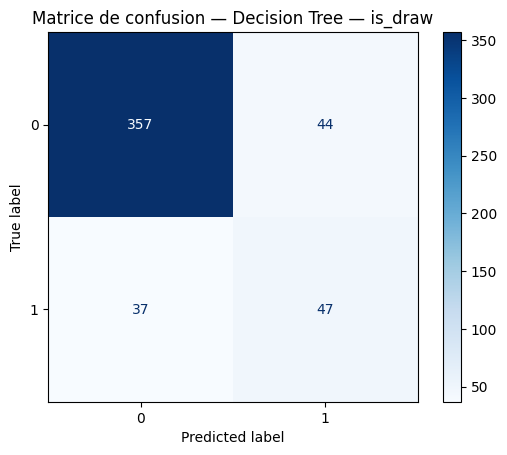

In [37]:
# ── 3.1 Decision Tree ────────────────────────────────────────
dt_xw = DecisionTreeClassifier(random_state=42)
dt_xw.fit(X_train, y_train_xw)

dt_dr = DecisionTreeClassifier(random_state=42)
dt_dr.fit(X_train, y_train_dr)

acc_xw_dt, f1_xw_dt = evaluer_modele(
    'Decision Tree — x_wins',  dt_xw, X_test, y_test_xw)
acc_dr_dt, f1_dr_dt = evaluer_modele(
    'Decision Tree — is_draw', dt_dr, X_test, y_test_dr)

=== Random Forest — x_wins ===
  Accuracy : 0.8784
  F1-Score : 0.8692



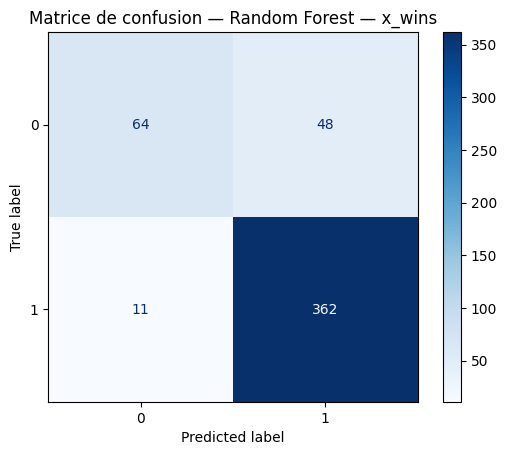

=== Random Forest — is_draw ===
  Accuracy : 0.9052
  F1-Score : 0.8908



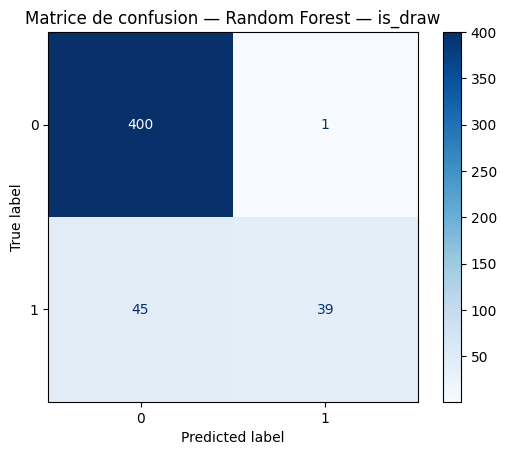

In [38]:
# ── 3.2 Random Forest ────────────────────────────────────────
rf_xw = RandomForestClassifier(n_estimators=100, random_state=42)
rf_xw.fit(X_train, y_train_xw)

rf_dr = RandomForestClassifier(n_estimators=100, random_state=42)
rf_dr.fit(X_train, y_train_dr)

acc_xw_rf, f1_xw_rf = evaluer_modele(
    'Random Forest — x_wins',  rf_xw, X_test, y_test_xw)
acc_dr_rf, f1_dr_rf = evaluer_modele(
    'Random Forest — is_draw', rf_dr, X_test, y_test_dr)

=== XGBoost — x_wins ===
  Accuracy : 0.9381
  F1-Score : 0.9371



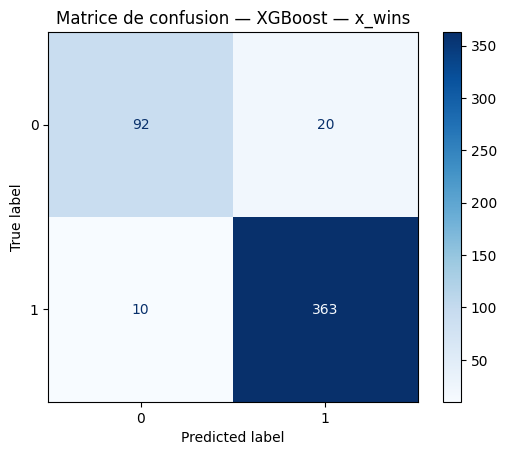

=== XGBoost — is_draw ===
  Accuracy : 0.9196
  F1-Score : 0.9164



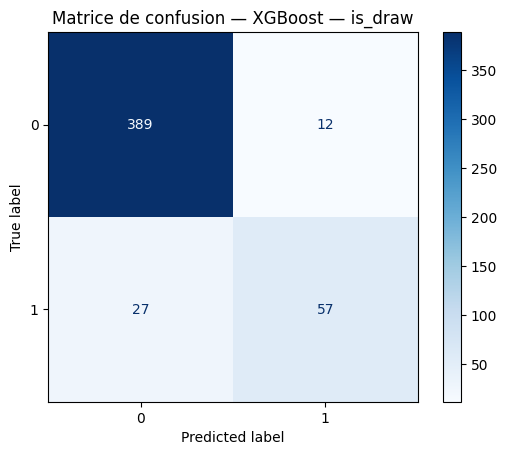

In [39]:
# ── 3.3 XGBoost ──────────────────────────────────────────────
xgb_xw = XGBClassifier(n_estimators=100, random_state=42,
                        eval_metric='logloss')
xgb_xw.fit(X_train, y_train_xw)

xgb_dr = XGBClassifier(n_estimators=100, random_state=42,
                        eval_metric='logloss')
xgb_dr.fit(X_train, y_train_dr)

acc_xw_xgb, f1_xw_xgb = evaluer_modele(
    'XGBoost — x_wins',  xgb_xw, X_test, y_test_xw)
acc_dr_xgb, f1_dr_xgb = evaluer_modele(
    'XGBoost — is_draw', xgb_dr, X_test, y_test_dr)

=== MLP — x_wins ===
  Accuracy : 0.9155
  F1-Score : 0.9161



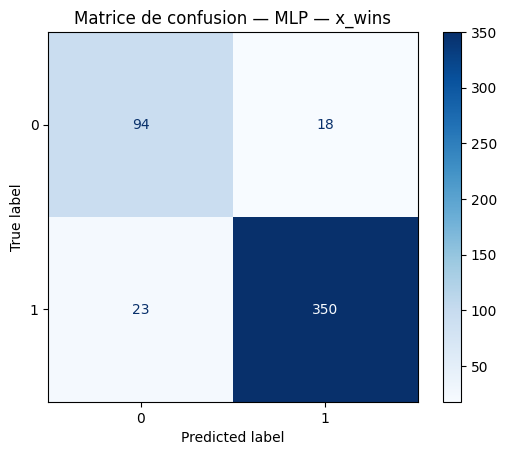

=== MLP — is_draw ===
  Accuracy : 0.9485
  F1-Score : 0.9478



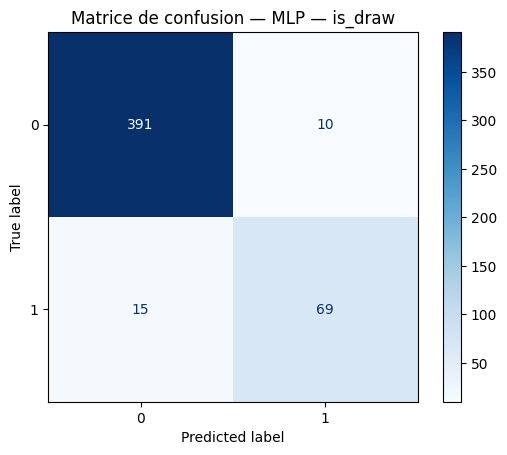

In [40]:
# ── 3.4 Réseau de Neurones (MLP) ─────────────────────────────
from sklearn.neural_network import MLPClassifier

# x_wins
mlp_xw = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 couches cachées : 64 puis 32 neurones
    activation='relu',            # fonction d'activation
    max_iter=500,                 # nombre max d'itérations
    random_state=42
)
mlp_xw.fit(X_train, y_train_xw)

# is_draw
mlp_dr = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42
)
mlp_dr.fit(X_train, y_train_dr)

acc_xw_mlp, f1_xw_mlp = evaluer_modele(
    'MLP — x_wins',  mlp_xw, X_test, y_test_xw)
acc_dr_mlp, f1_dr_mlp = evaluer_modele(
    'MLP — is_draw', mlp_dr, X_test, y_test_dr)

=== Gradient Boosting — x_wins ===
  Accuracy : 0.8392
  F1-Score : 0.8275



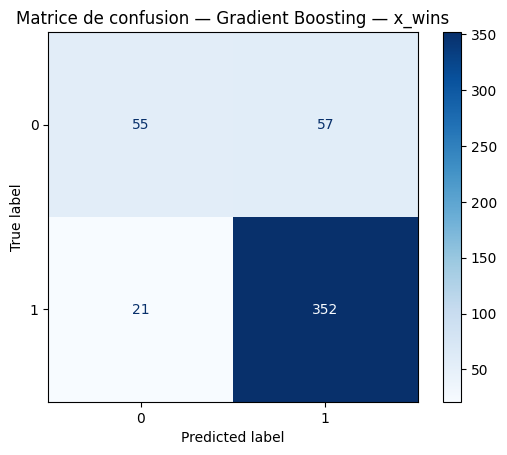

=== Gradient Boosting — is_draw ===
  Accuracy : 0.8763
  F1-Score : 0.8587



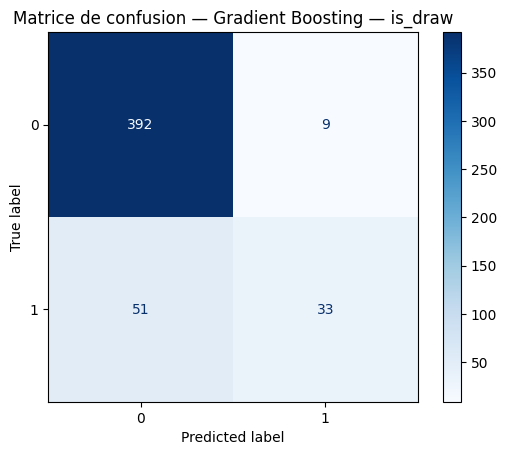

In [41]:
# ── 3.5 Gradient Boosting ────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier

# x_wins
gb_xw = GradientBoostingClassifier(
    n_estimators=100,   # nombre d'arbres
    learning_rate=0.1,  # taux d'apprentissage
    max_depth=3,        # profondeur max de chaque arbre
    random_state=42
)
gb_xw.fit(X_train, y_train_xw)

# is_draw
gb_dr = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_dr.fit(X_train, y_train_dr)

acc_xw_gb, f1_xw_gb = evaluer_modele(
    'Gradient Boosting — x_wins',  gb_xw, X_test, y_test_xw)
acc_dr_gb, f1_dr_gb = evaluer_modele(
    'Gradient Boosting — is_draw', gb_dr, X_test, y_test_dr)

---
## 4. Résumé comparatif final <a id='resume'></a>

In [42]:
# ── Tableau comparatif FINAL complet ─────────────────────────
resultats = pd.DataFrame({
    'Modèle': [
        'Régression Logistique', 'Régression Logistique',
        'Decision Tree',         'Decision Tree',
        'Random Forest',         'Random Forest',
        'XGBoost',               'XGBoost',
        'MLP',                   'MLP',
        'Gradient Boosting',     'Gradient Boosting',
    ],
    'Cible': [
        'x_wins', 'is_draw',
        'x_wins', 'is_draw',
        'x_wins', 'is_draw',
        'x_wins', 'is_draw',
        'x_wins', 'is_draw',
        'x_wins', 'is_draw',
    ],
    'Accuracy': [
        round(acc_xw_lr,  4), round(acc_dr_lr,  4),
        round(acc_xw_dt,  4), round(acc_dr_dt,  4),
        round(acc_xw_rf,  4), round(acc_dr_rf,  4),
        round(acc_xw_xgb, 4), round(acc_dr_xgb, 4),
        round(acc_xw_mlp, 4), round(acc_dr_mlp, 4),
        round(acc_xw_gb,  4), round(acc_dr_gb,  4),
    ],
    'F1-Score': [
        round(f1_xw_lr,  4), round(f1_dr_lr,  4),
        round(f1_xw_dt,  4), round(f1_dr_dt,  4),
        round(f1_xw_rf,  4), round(f1_dr_rf,  4),
        round(f1_xw_xgb, 4), round(f1_dr_xgb, 4),
        round(f1_xw_mlp, 4), round(f1_dr_mlp, 4),
        round(f1_xw_gb,  4), round(f1_dr_gb,  4),
    ]
})

print(resultats.to_string(index=False))

               Modèle   Cible  Accuracy  F1-Score
Régression Logistique  x_wins    0.7876    0.7336
Régression Logistique is_draw    0.8268    0.7484
        Decision Tree  x_wins    0.7918    0.7972
        Decision Tree is_draw    0.8330    0.8356
        Random Forest  x_wins    0.8784    0.8692
        Random Forest is_draw    0.9052    0.8908
              XGBoost  x_wins    0.9381    0.9371
              XGBoost is_draw    0.9196    0.9164
                  MLP  x_wins    0.9155    0.9161
                  MLP is_draw    0.9485    0.9478
    Gradient Boosting  x_wins    0.8392    0.8275
    Gradient Boosting is_draw    0.8763    0.8587


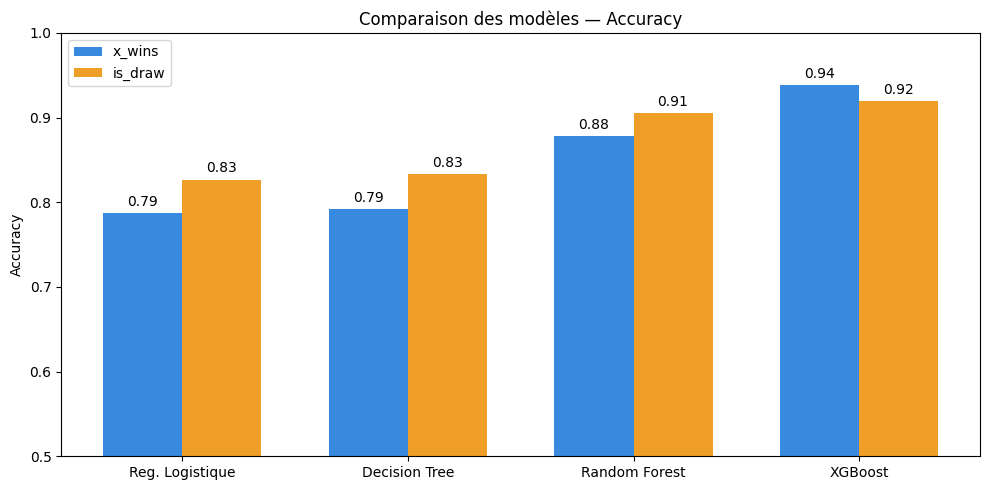

In [43]:
# ── Graphique comparatif ─────────────────────────────────────
modeles   = ['Reg. Logistique', 'Decision Tree', 'Random Forest', 'XGBoost']
acc_xwins = [acc_xw_lr, acc_xw_dt, acc_xw_rf, acc_xw_xgb]
acc_draw  = [acc_dr_lr, acc_dr_dt, acc_dr_rf, acc_dr_xgb]

x = np.arange(len(modeles))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, acc_xwins, width,
               label='x_wins', color='#378ADD')
bars2 = ax.bar(x + width/2, acc_draw,  width,
               label='is_draw', color='#EF9F27')

ax.set_ylabel('Accuracy')
ax.set_title('Comparaison des modèles — Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(modeles)
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=3)
ax.bar_label(bars2, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

---
## Exportation du ML avec JobLib

In [44]:
import joblib
joblib.dump(xgb_xw, 'ressources/model_xwins.pkl')
joblib.dump(xgb_dr, 'ressources/model_draw.pkl')

['ressources/model_draw.pkl']